In [1]:
!pip install -U pyarrow datasets transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 190.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 214.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 637.4/637.4 kB 633.4 MB/s  0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 17.0.0
    Uninstalling pyarrow-17.0.0:
      Successfully uninstalled pyarrow-17.0.0
  Attempting uninstall: dill━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/7 [pyarrow]
    Found existing installation: dill 0.3.9━━━━━━━━━━━━━━━━━━━ 1/7 [pyarrow]
    Uninstalling dill-0.3.9:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/7 [pyarrow]
      Successfully uninstalled dill-0.3.9━━━━━━━━━━━━━━━━━━━━━ 1/7 [pyarrow]
  Attempting uninstall: click━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/7 [pyarrow]
    Found existing installation: click 8.1.8━━━━━━━━━━━━━━━━━━ 1/7 [pyarrow]
    Uninstalling click-8.1.8:━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/7 [pyarrow]
      Successfully uninstalled click-8.1.80m━━━━━━━━━━━━━

In [3]:
import pandas as pd
import numpy as np
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

# --- 1. CARGA DE DATOS ---
# Asegúrate de haber corrido el generador del CSV antes
dataset = load_dataset('csv', data_files='t-moviles_dataset.csv')
dataset = dataset['train'].train_test_split(test_size=0.2)

# --- 2. TOKENIZACIÓN ---
model_name = "dccuchile/bert-base-spanish-wwm-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_func(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

# Aquí definimos la variable que te daba error
tokenized_datasets = dataset.map(tokenize_func, batched=True)

# --- 3. CONFIGURACIÓN DEL MODELO Y ENTRENAMIENTO ---
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=4)

# Ajuste de argumentos para evitar el warning de logging_dir y optimizar memoria
training_args = TrainingArguments(
    output_dir="./results_t-moviles",
    eval_strategy="epoch",  # Actualizado para evitar deprecación
    learning_rate=2e-5,
    per_device_train_batch_size=4, 
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    logging_steps=10,
    fp16=torch.cuda.is_available() # Usa precisión mixta si detecta GPU
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": (predictions == labels).astype(np.float32).mean().item()}

# --- 4. INICIALIZACIÓN DEL TRAINER ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
)

# --- 5. ¡A ENTRENAR! ---
print("Iniciando el Fine-tuning para T-Moviles Argentina...")
trainer.train()

model_path = "./modelo_t-moviles_pytorch"
trainer.save_model(model_path)
tokenizer.save_pretrained(model_path)

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not 

Iniciando el Fine-tuning para T-Moviles Argentina...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./modelo_t-moviles_pytorch/tokenizer_config.json',
 './modelo_t-moviles_pytorch/tokenizer.json')

In [5]:
!pip install -q seaborn matplotlib

Calculando predicciones sobre el set de test...


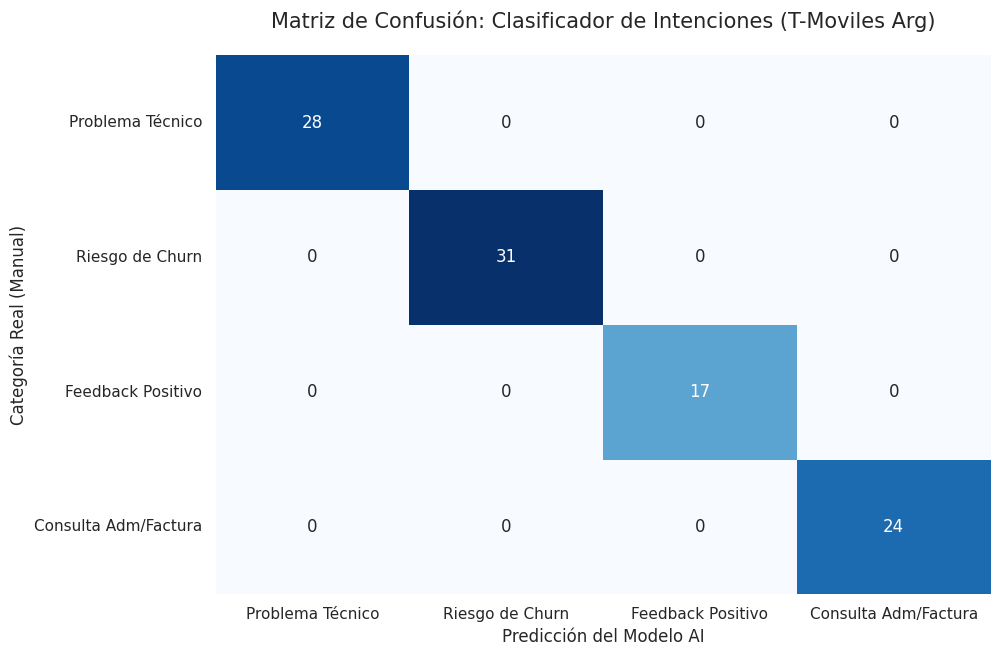


 REPORTES DE MÉTRICAS DETALLADAS
                      precision    recall  f1-score   support

    Problema Técnico       1.00      1.00      1.00        28
     Riesgo de Churn       1.00      1.00      1.00        31
   Feedback Positivo       1.00      1.00      1.00        17
Consulta Adm/Factura       1.00      1.00      1.00        24

            accuracy                           1.00       100
           macro avg       1.00      1.00      1.00       100
        weighted avg       1.00      1.00      1.00       100



In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# 1. Obtener predicciones del set de validación (usando el objeto trainer que ya tenés)
print("Calculando predicciones sobre el set de test...")
output = trainer.predict(tokenized_datasets["test"])
preds = np.argmax(output.predictions, axis=-1)
labels = output.label_ids

# 2. Definir etiquetas (Mapeo de tu dataset sintético)
# 0: Técnico, 1: Churn, 2: Positivo, 3: Administrativo
target_names = ['Problema Técnico', 'Riesgo de Churn', 'Feedback Positivo', 'Consulta Adm/Factura']

# 3. Configurar el estilo visual
sns.set_theme(style="white")
cm = confusion_matrix(labels, preds)

# 4. Crear el Gráfico
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names,
            cbar=False)

plt.title('Matriz de Confusión: Clasificador de Intenciones (T-Moviles Arg)', fontsize=15, pad=20)
plt.xlabel('Predicción del Modelo AI', fontsize=12)
plt.ylabel('Categoría Real (Manual)', fontsize=12)
plt.show()

# 5. Reporte de Texto
print("\n" + "="*30)
print(" REPORTES DE MÉTRICAS DETALLADAS")
print("="*30)
print(classification_report(labels, preds, target_names=target_names))